# test_h01_match

Plot matched H01 diagnostics from new `U01` outputs.

- Loads `U01grid_*` from `numpy_grid/h{h}_eps{eps}/U01Grids/`
- Converts `u=h01/r^2` back to `h01` and `h01'`
- Reproduces old notebook style plots after matching


In [25]:
import pickle
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
from scipy.special import hyp2f1
from tqdm import tqdm

BASE = Path.cwd().resolve().parent  # .../high_bg_order_sol
if BASE.name != 'high_bg_order_sol':
    BASE = Path.cwd().resolve()

CFG_PATH = BASE / 'config' / 'h_eps_config.pkl'
with open(CFG_PATH, 'rb') as f:
    cfg = pickle.load(f)

h_tok = str(cfg['h'])
eps_tok = str(cfg['eps'])
target_dir = BASE / 'numpy_grid' / f'h{h_tok}_eps{eps_tok}'
u01_dir = target_dir / 'U01Grids'

print('BASE      :', BASE)
print('target_dir:', target_dir)
print('u01_dir   :', u01_dir)


BASE      : /Users/sztk.ch/Work/grad-school/Research/TLN-TDN Project/Programs/Equation Solver/high_bg_order_sol
target_dir: /Users/sztk.ch/Work/grad-school/Research/TLN-TDN Project/Programs/Equation Solver/high_bg_order_sol/numpy_grid/h1e-4_eps1e-3
u01_dir   : /Users/sztk.ch/Work/grad-school/Research/TLN-TDN Project/Programs/Equation Solver/high_bg_order_sol/numpy_grid/h1e-4_eps1e-3/U01Grids


In [26]:
# Load background radius grid
r_path = target_dir / f'RGrid_h{h_tok}_eps{eps_tok}.pkl'
if not r_path.exists():
    alt = target_dir / f'Rgrid_h{h_tok}_eps{eps_tok}.pkl'
    if alt.exists():
        r_path = alt

with open(r_path, 'rb') as f:
    Rgrid = pickle.load(f)

with open(u01_dir / f'U01grid_hom_h{h_tok}_eps{eps_tok}.pkl', 'rb') as f:
    U01Hom_Grid = pickle.load(f)
with open(u01_dir / f'U01grid_full_h{h_tok}_eps{eps_tok}.pkl', 'rb') as f:
    U01Full_Grid = pickle.load(f)
with open(u01_dir / f'U01grid_part_h{h_tok}_eps{eps_tok}.pkl', 'rb') as f:
    U01Part_Grid = pickle.load(f)
with open(u01_dir / f'U01grid_matched_h{h_tok}_eps{eps_tok}.pkl', 'rb') as f:
    U01Matched_Grid = pickle.load(f)

with open(u01_dir / f'H01Match_h{h_tok}_eps{eps_tok}.pkl', 'rb') as f:
    match_payload = pickle.load(f)

records = match_payload['records']
n_models = min(len(Rgrid), len(U01Hom_Grid), len(records))
print('n_models:', n_models)


n_models: 25


In [27]:
def u_to_h_arrays(u_sol, r_arr):
    u = np.asarray(u_sol)[:, 0]
    up = np.asarray(u_sol)[:, 1]
    r = np.asarray(r_arr)
    h = (r ** 2) * u
    hp = (r ** 2) * up + 2.0 * r * u
    return h, hp

def mh2r_l2_hypergeom_and_derivative(r, m_tot):
    l = 2
    z = 2.0 * m_tot / r
    x = m_tot / r
    f = 1.0 - z

    F = hyp2f1(l + 1, l + 3, 2 * l + 2, z)
    h_ext = f * (x ** (l + 1)) * F

    a, b, c = l + 1, l + 3, 2 * l + 2
    dF_dz = (a * b / c) * hyp2f1(a + 1, b + 1, c + 1, z)

    df_dr = 2.0 * m_tot / (r * r)
    dx3_dr = -(l + 1) * (x ** (l + 1)) / r
    dz_dr = -2.0 * m_tot / (r * r)
    dF_dr = dF_dz * dz_dr

    dh_dr = df_dr * (x ** (l + 1)) * F + f * dx3_dr * F + f * (x ** (l + 1)) * dF_dr

    mh = m_tot * h_ext
    dmh = m_tot * dh_dr
    mh = np.real_if_close(mh, tol=1e5)
    dmh = np.real_if_close(dmh, tol=1e5)
    return np.real(mh), np.real(dmh)

def grid_shape(n):
    if n <= 5:
        return 1, n
    if n <= 10:
        return 2, 5
    if n <= 15:
        return 3, 5
    if n <= 20:
        return 4, 5
    if n <= 25:
        return 5, 5
    cols = int(np.ceil(np.sqrt(n)))
    rows = int(np.ceil(n / cols))
    return rows, cols


In [28]:
n_plot = n_models

plot_data = []
for i in tqdm(range(n_plot), desc='Build plot data'):
    rec = records[i]
    surface_idx = int(rec['surface_index'])

    r_use = np.asarray(Rgrid[i], dtype=float)[:surface_idx]

    h_hom, hp_hom = u_to_h_arrays(U01Hom_Grid[i], r_use)
    h_full, hp_full = u_to_h_arrays(U01Full_Grid[i], r_use)
    h_part, hp_part = u_to_h_arrays(U01Part_Grid[i], r_use)
    h_matched, hp_matched = u_to_h_arrays(U01Matched_Grid[i], r_use)

    A0 = rec.get('A0', np.nan)
    I2m = rec.get('I2m', np.nan)
    M_tot = float(rec['M_tot'])

    ext_h = np.zeros_like(r_use)
    ext_hp = np.zeros_like(r_use)
    for j, rr in enumerate(r_use):
        mh, dmh = mh2r_l2_hypergeom_and_derivative(rr, M_tot)
        ext_h[j] = I2m * mh
        ext_hp[j] = I2m * dmh

    h_hom_matched = A0 * h_hom

    plot_data.append({
        'r': r_use,
        'h_full': h_full,
        'hp_full': hp_full,
        'h_hom_matched': h_hom_matched,
        'h_part': h_part,
        'hp_part': hp_part,
        'h_matched': h_matched,
        'hp_matched': hp_matched,
        'h_ext_matched': ext_h,
        'hp_ext_matched': ext_hp,
        'A0': A0,
        'I2m': I2m,
        'status': rec.get('status', 'unknown'),
    })

print('Prepared stars:', len(plot_data))


Build plot data:   0%|          | 0/25 [00:00<?, ?it/s]/var/folders/2w/8nb8998n2h38fndcsz3s5wq80000gn/T/ipykernel_17738/2471814065.py:26: RuntimeWarning: invalid value encountered in scalar add
  dh_dr = df_dr * (x ** (l + 1)) * F + f * dx3_dr * F + f * (x ** (l + 1)) * dF_dr
Build plot data: 100%|██████████| 25/25 [00:26<00:00,  1.07s/it]

Prepared stars: 25


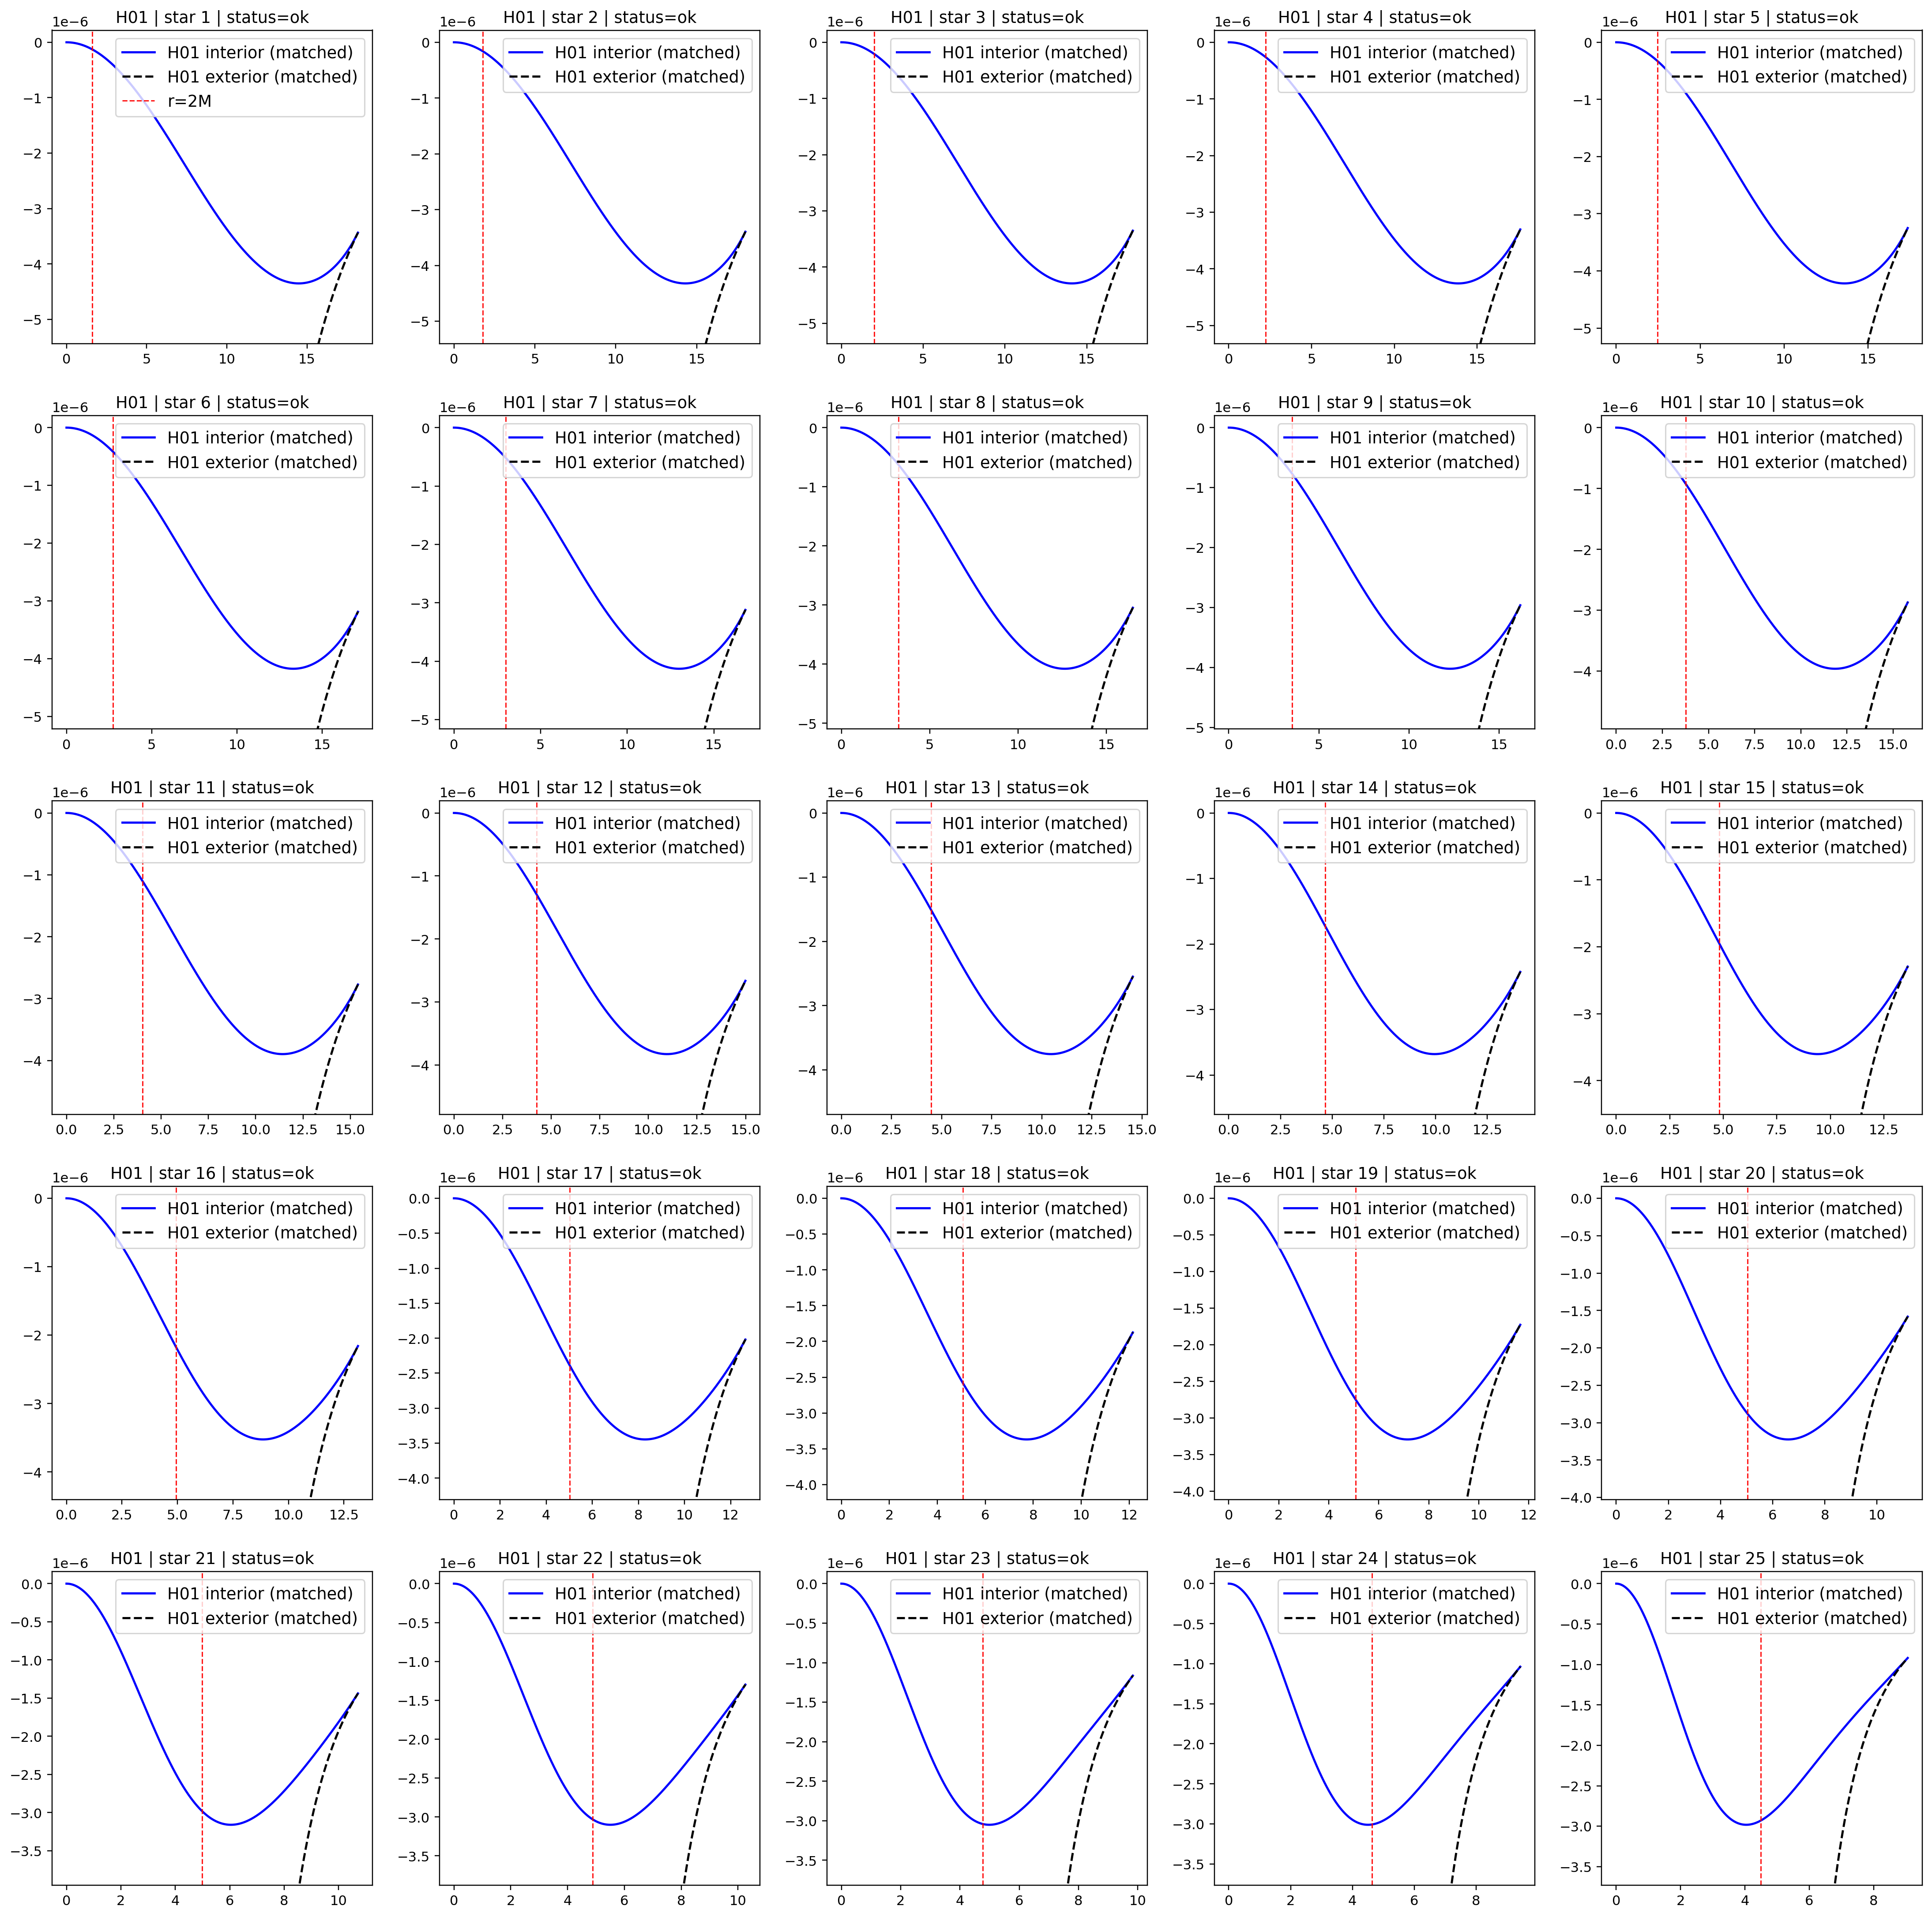

In [29]:
# 1) H01 Match Check: H01 interior vs H01 exterior
rows, cols = grid_shape(n_plot)
fig, axs = plt.subplots(rows, cols, figsize=(20, 4 * rows), dpi=220)
axs = np.atleast_1d(axs).reshape(rows, cols)

for i in range(rows * cols):
    ax = axs[i // cols, i % cols]
    if i >= n_plot:
        ax.axis('off')
        continue

    d = plot_data[i]
    r_s = 2.0 * records[i]['M_tot']
    ax.plot(d['r'], d['h_matched'], color='blue', lw=1.6, label='H01 interior (matched)')
    ax.plot(d['r'], d['h_ext_matched'], color='black', lw=1.6, ls='--', label='H01 exterior (matched)')
    ax.axvline(r_s, color='red', ls='--', lw=1.0, alpha=0.9, label='r=2M' if i == 0 else None)
    ax.set_title(f'H01 | star {i+1} | status={d["status"]}')
    ax.legend(fontsize=12)

    scale = max(d['h_matched']) - min(d['h_matched'])
    ax.set_ylim(min(d['h_matched']) - 0.25*scale, max(d['h_matched']) + 0.05*scale)

fig.tight_layout()
plt.show()

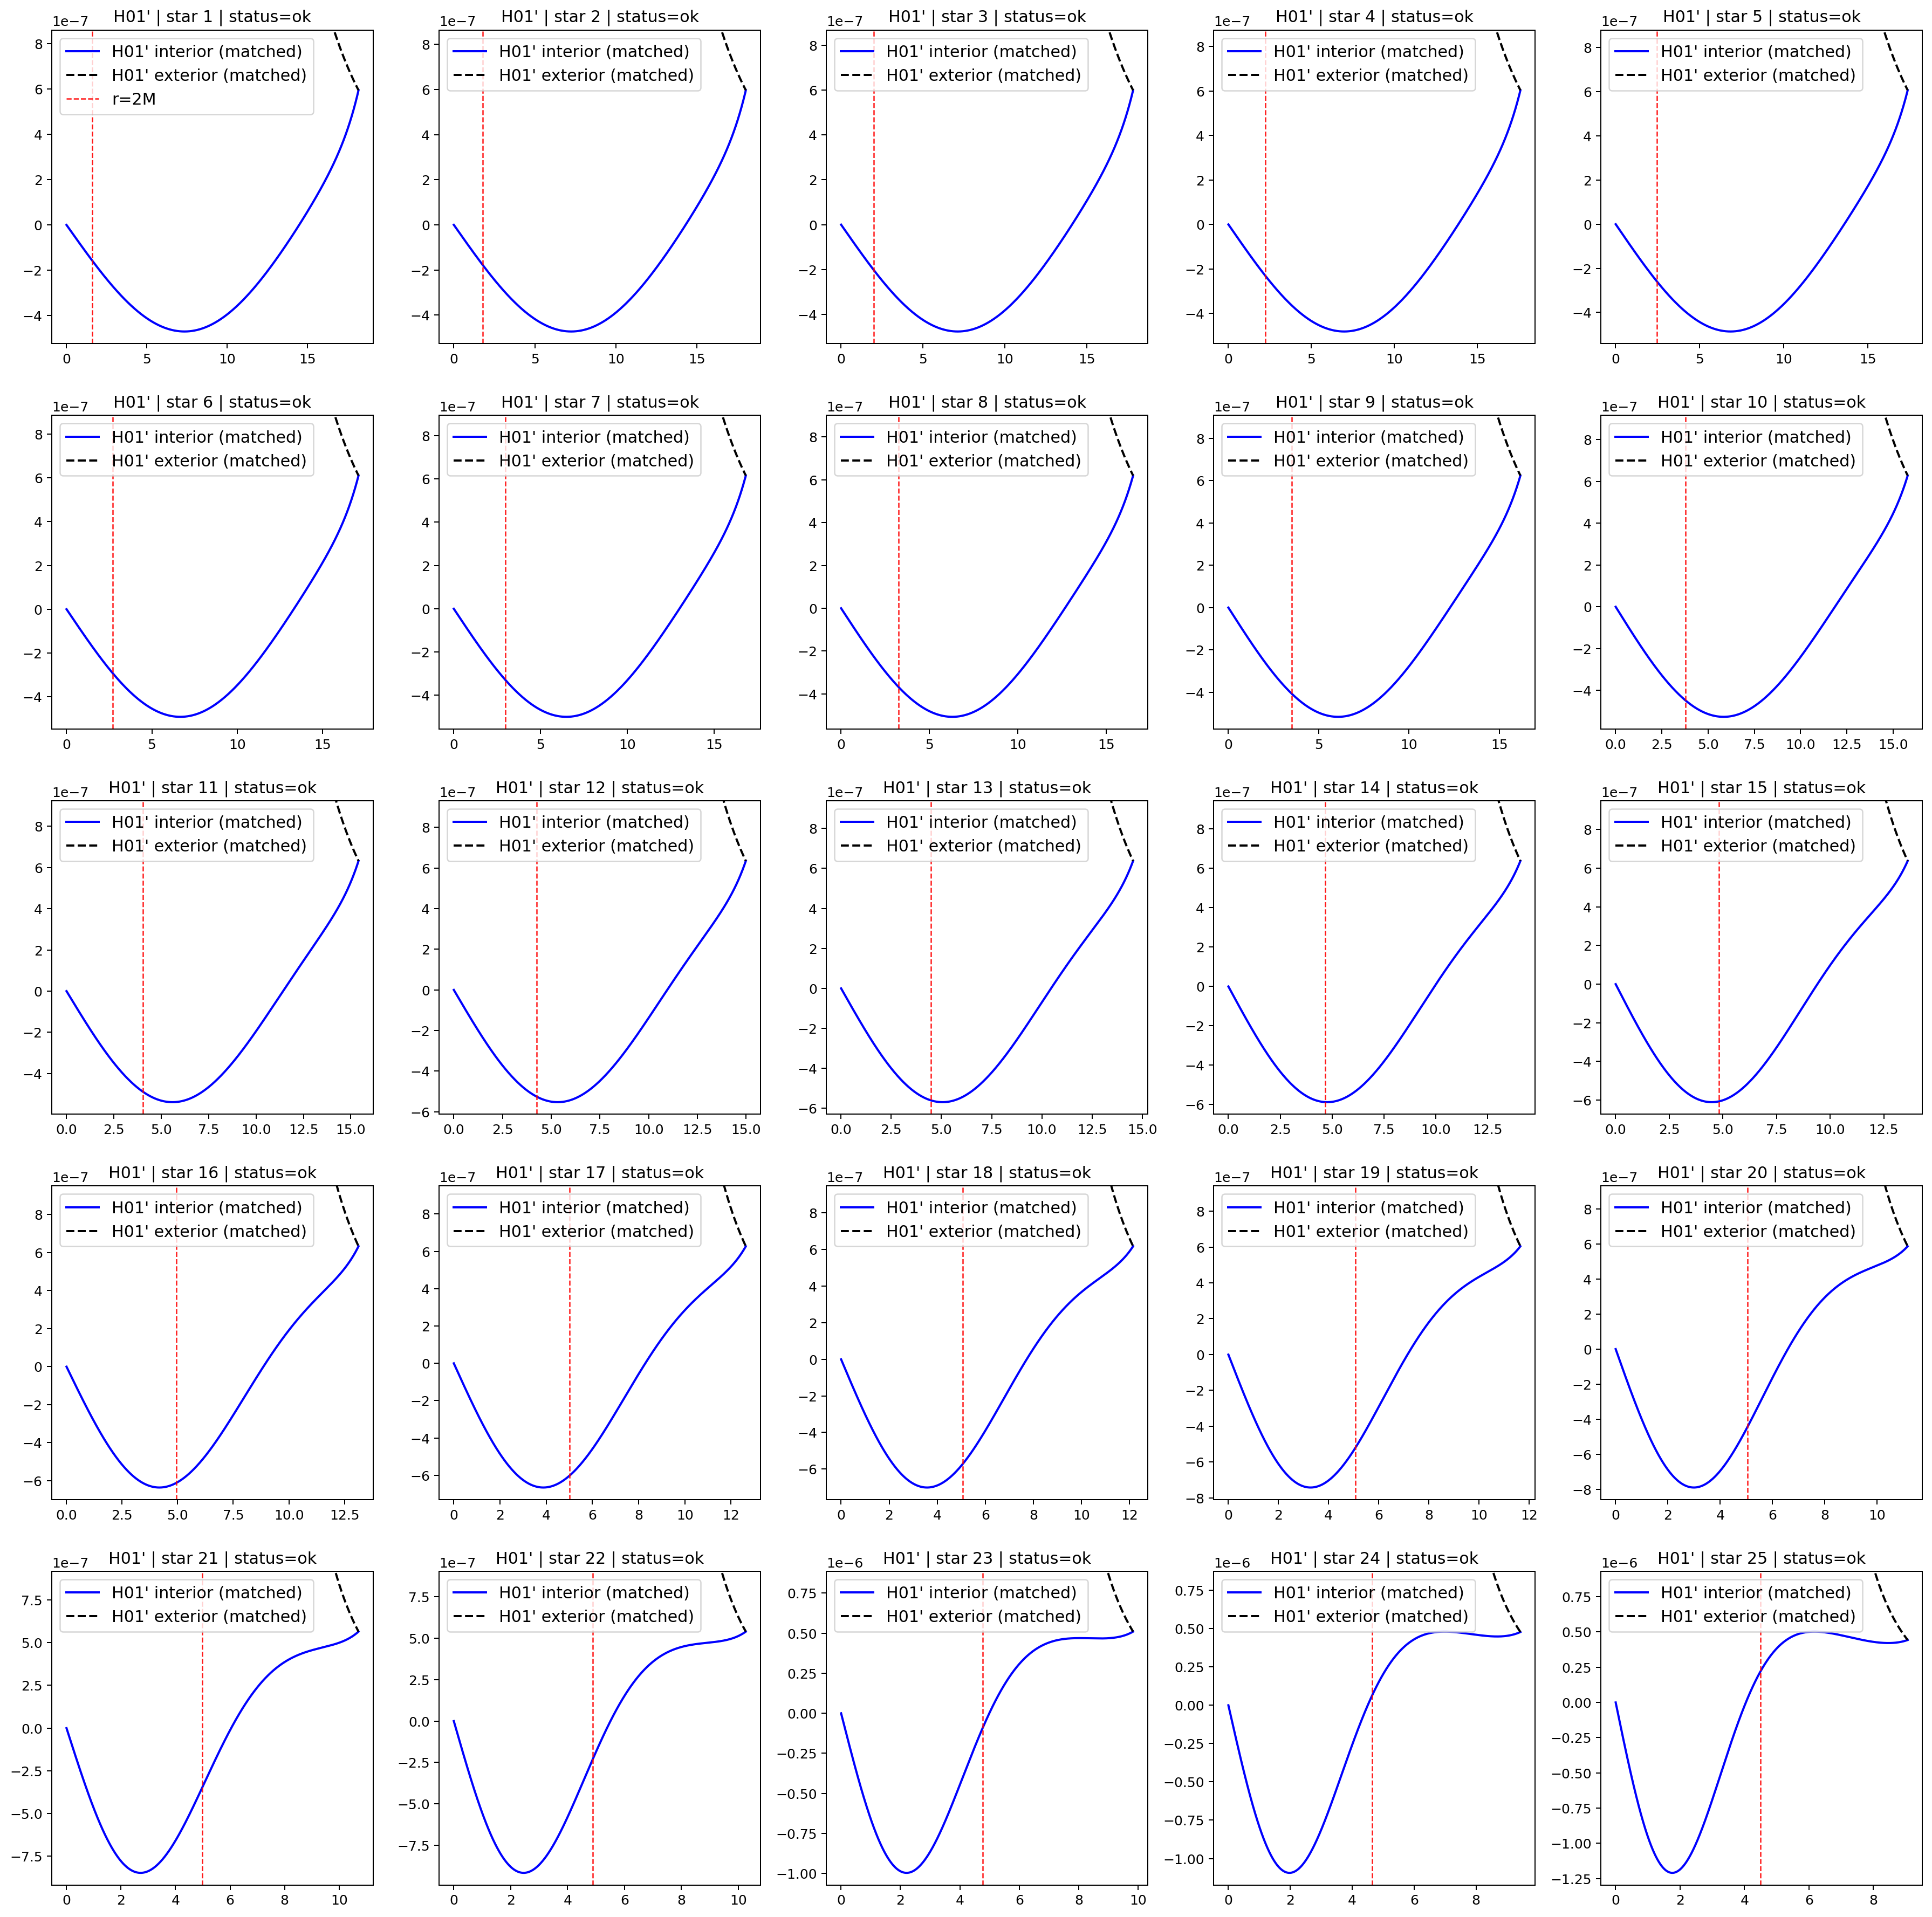

In [30]:
# 2) H01' Match Check: H01' interior vs H01' exterior
rows, cols = grid_shape(n_plot)
fig, axs = plt.subplots(rows, cols, figsize=(20, 4 * rows), dpi=180)
axs = np.atleast_1d(axs).reshape(rows, cols)

for i in range(rows * cols):
    ax = axs[i // cols, i % cols]
    if i >= n_plot:
        ax.axis('off')
        continue

    d = plot_data[i]
    r_s = 2.0 * records[i]['M_tot']
    ax.plot(d['r'], d['hp_matched'], color='blue', lw=1.6, label="H01' interior (matched)")
    ax.plot(d['r'], d['hp_ext_matched'], color='black', lw=1.6, ls='--', label="H01' exterior (matched)")
    ax.axvline(r_s, color='red', ls='--', lw=1.0, alpha=0.9, label='r=2M' if i == 0 else None)
    ax.set_title(f"H01' | star {i+1} | status={d['status']}")
    # ax.set_yscale("log")
    ax.legend(fontsize=12)

    scale = max(d['hp_matched']) - min(d['hp_matched'])
    ax.set_ylim(min(d['hp_matched']) - 0.05*scale, max(d['hp_matched']) + 0.25*scale)

fig.tight_layout()
plt.show()


/var/folders/2w/8nb8998n2h38fndcsz3s5wq80000gn/T/ipykernel_17738/1720167779.py:27: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


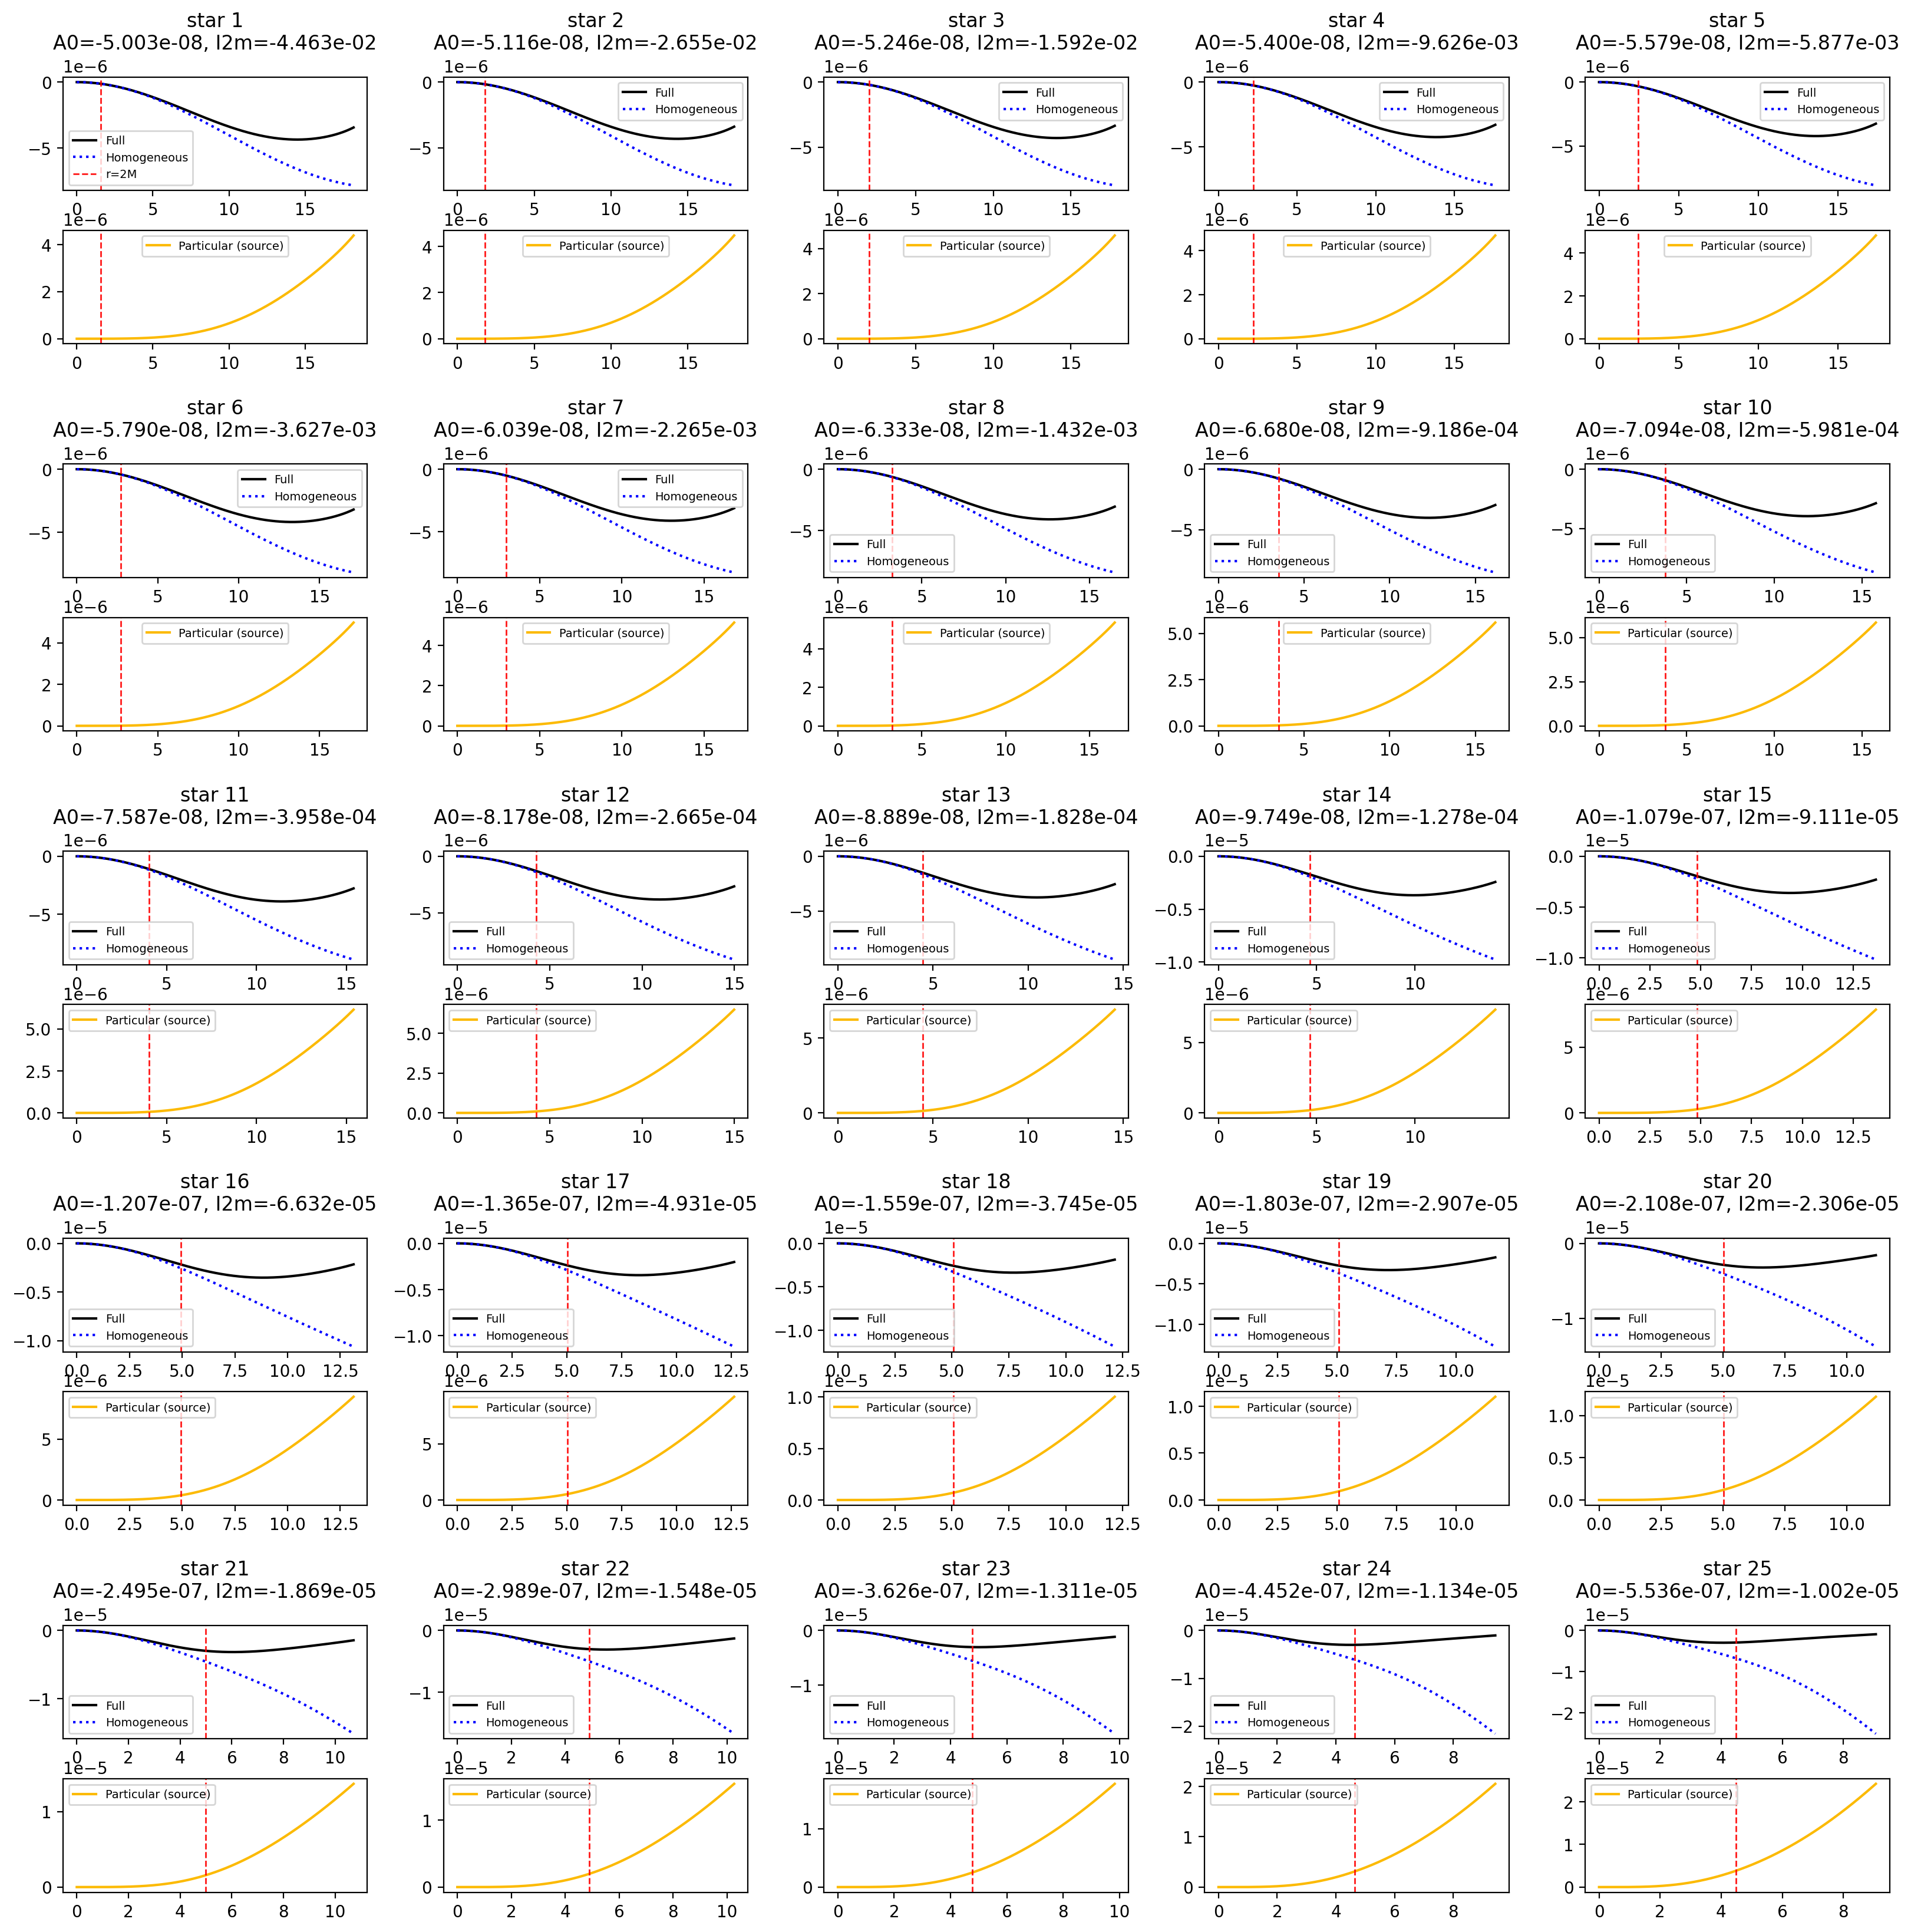

In [31]:
rows, cols = grid_shape(n_plot)
fig = plt.figure(figsize=(20, 4 * rows), dpi=200)
outer = fig.add_gridspec(rows, cols, wspace=0.25, hspace=0.45)

for i in range(n_plot):
    d = plot_data[i]
    r_s = 2.0 * records[i]['M_tot']

    inner = outer[i // cols, i % cols].subgridspec(2, 1, height_ratios=[1, 1], hspace=0.35)
    ax_top = fig.add_subplot(inner[0])
    ax_bot = fig.add_subplot(inner[1], sharex=ax_top)

    ax_top.plot(d['r'], d['h_matched'], label='Full', color='black', lw=1.5)
    ax_top.plot(d['r'], d['h_hom_matched'], label='Homogeneous', color='blue', ls=':', lw=1.5)
    ax_top.axvline(r_s, color='red', ls='--', lw=1.0, alpha=0.9, label='r=2M' if i == 0 else None)
    ax_top.set_title(f'star {i+1}\nA0={d["A0"]:.3e}, I2m={d["I2m"]:.3e}')
    ax_top.legend(fontsize=7)

    ax_bot.plot(d['r'], d['h_part'], label='Particular (source)', color='#fcba03', lw=1.5)
    ax_bot.axvline(r_s, color='red', ls='--', lw=1.0, alpha=0.9)
    ax_bot.legend(fontsize=7)

for i in range(n_plot, rows * cols):
    ax = fig.add_subplot(outer[i // cols, i % cols])
    ax.axis('off')

fig.tight_layout()
plt.show()


## H00 Match Check (from U00)

Load `U00grid` and `E0I0_from_u00` to verify static (`l=2`) matching at/near the surface.


In [32]:
# Load U00 and solved static coefficients (E0, I0)
with open(target_dir / f'U00grid_h{h_tok}_eps{eps_tok}.pkl', 'rb') as f:
    U00Grid = pickle.load(f)

e0i0_path = target_dir / f'E0I0_from_u00_h{h_tok}_eps{eps_tok}.pkl'
with open(e0i0_path, 'rb') as f:
    e0i0_payload = pickle.load(f)

e0i0_records = e0i0_payload['records']
n_plot_h00 = min(n_plot, len(U00Grid), len(e0i0_records))
print('e0i0_path  :', e0i0_path)
print('n_plot_h00 :', n_plot_h00)

def H2R_static(r, m_tot):
    z = 2.0 * m_tot / r
    f = 1.0 - z
    return f * (m_tot / r) ** 3 * hyp2f1(3, 5, 6, z)

def H2T_static_c4(r, m_tot):
    f = 1.0 - 2.0 * m_tot / r
    return f * (r / m_tot) ** 2

h00_match_plot_data = []
for i in tqdm(range(n_plot_h00), desc='Build H00 match plot data'):
    rec = e0i0_records[i]
    sidx = int(rec['surface_index'])
    r_use = np.asarray(Rgrid[i], dtype=float)[:sidx+1]

    u_arr = np.asarray(U00Grid[i])[:sidx+1, 0]
    up_arr = np.asarray(U00Grid[i])[:sidx+1, 1]

    h_in = (r_use ** 2) * u_arr
    hp_in = (r_use ** 2) * up_arr + 2.0 * r_use * u_arr

    E0 = float(rec['E0'])
    I0 = float(rec['I0'])
    M_tot = float(rec['M_tot'])

    Ht = H2T_static_c4(r_use, M_tot)
    Hr = H2R_static(r_use, M_tot)
    h_out = E0 * Ht + I0 * Hr

    # Derivative of exterior reconstructed profile via one-sided FD in r
    hp_out = np.zeros_like(r_use)
    for j, rr in enumerate(r_use):
        dr_loc = max(1e-6 * rr, 5e-6)
        Ht_p = H2T_static_c4(rr + dr_loc, M_tot)
        Hr_p = H2R_static(rr + dr_loc, M_tot)
        h_out_p = E0 * Ht_p + I0 * Hr_p
        hp_out[j] = (h_out_p - h_out[j]) / dr_loc

    h00_match_plot_data.append({
        'r': r_use,
        'h_in': h_in,
        'hp_in': hp_in,
        'h_out': h_out,
        'hp_out': hp_out,
        'R': float(rec['R']),
        'M_tot': M_tot,
        'E0': E0,
        'I0': I0,
        'rel_err_hR': float(rec.get('rel_err_hR', np.nan)),
        'rel_err_hRp': float(rec.get('rel_err_hRp', np.nan)),
        'status': rec.get('status', 'unknown'),
    })

print('Prepared H00 stars:', len(h00_match_plot_data))


/var/folders/2w/8nb8998n2h38fndcsz3s5wq80000gn/T/ipykernel_17738/2960981866.py:3: DeprecationWarning: numpy.core.numeric is deprecated and has been renamed to numpy._core.numeric. The numpy._core namespace contains private NumPy internals and its use is discouraged, as NumPy internals can change without warning in any release. In practice, most real-world usage of numpy.core is to access functionality in the public NumPy API. If that is the case, use the public NumPy API. If not, you are using NumPy internals. If you would still like to access an internal attribute, use numpy._core.numeric._frombuffer.
  U00Grid = pickle.load(f)


e0i0_path  : /Users/sztk.ch/Work/grad-school/Research/TLN-TDN Project/Programs/Equation Solver/high_bg_order_sol/numpy_grid/h1e-4_eps1e-3/E0I0_from_u00_h1e-4_eps1e-3.pkl
n_plot_h00 : 25


Build H00 match plot data:   0%|          | 0/25 [00:00<?, ?it/s]/var/folders/2w/8nb8998n2h38fndcsz3s5wq80000gn/T/ipykernel_17738/2960981866.py:50: RuntimeWarning: invalid value encountered in scalar subtract
  hp_out[j] = (h_out_p - h_out[j]) / dr_loc
Build H00 match plot data: 100%|██████████| 25/25 [00:10<00:00,  2.42it/s]

Prepared H00 stars: 25


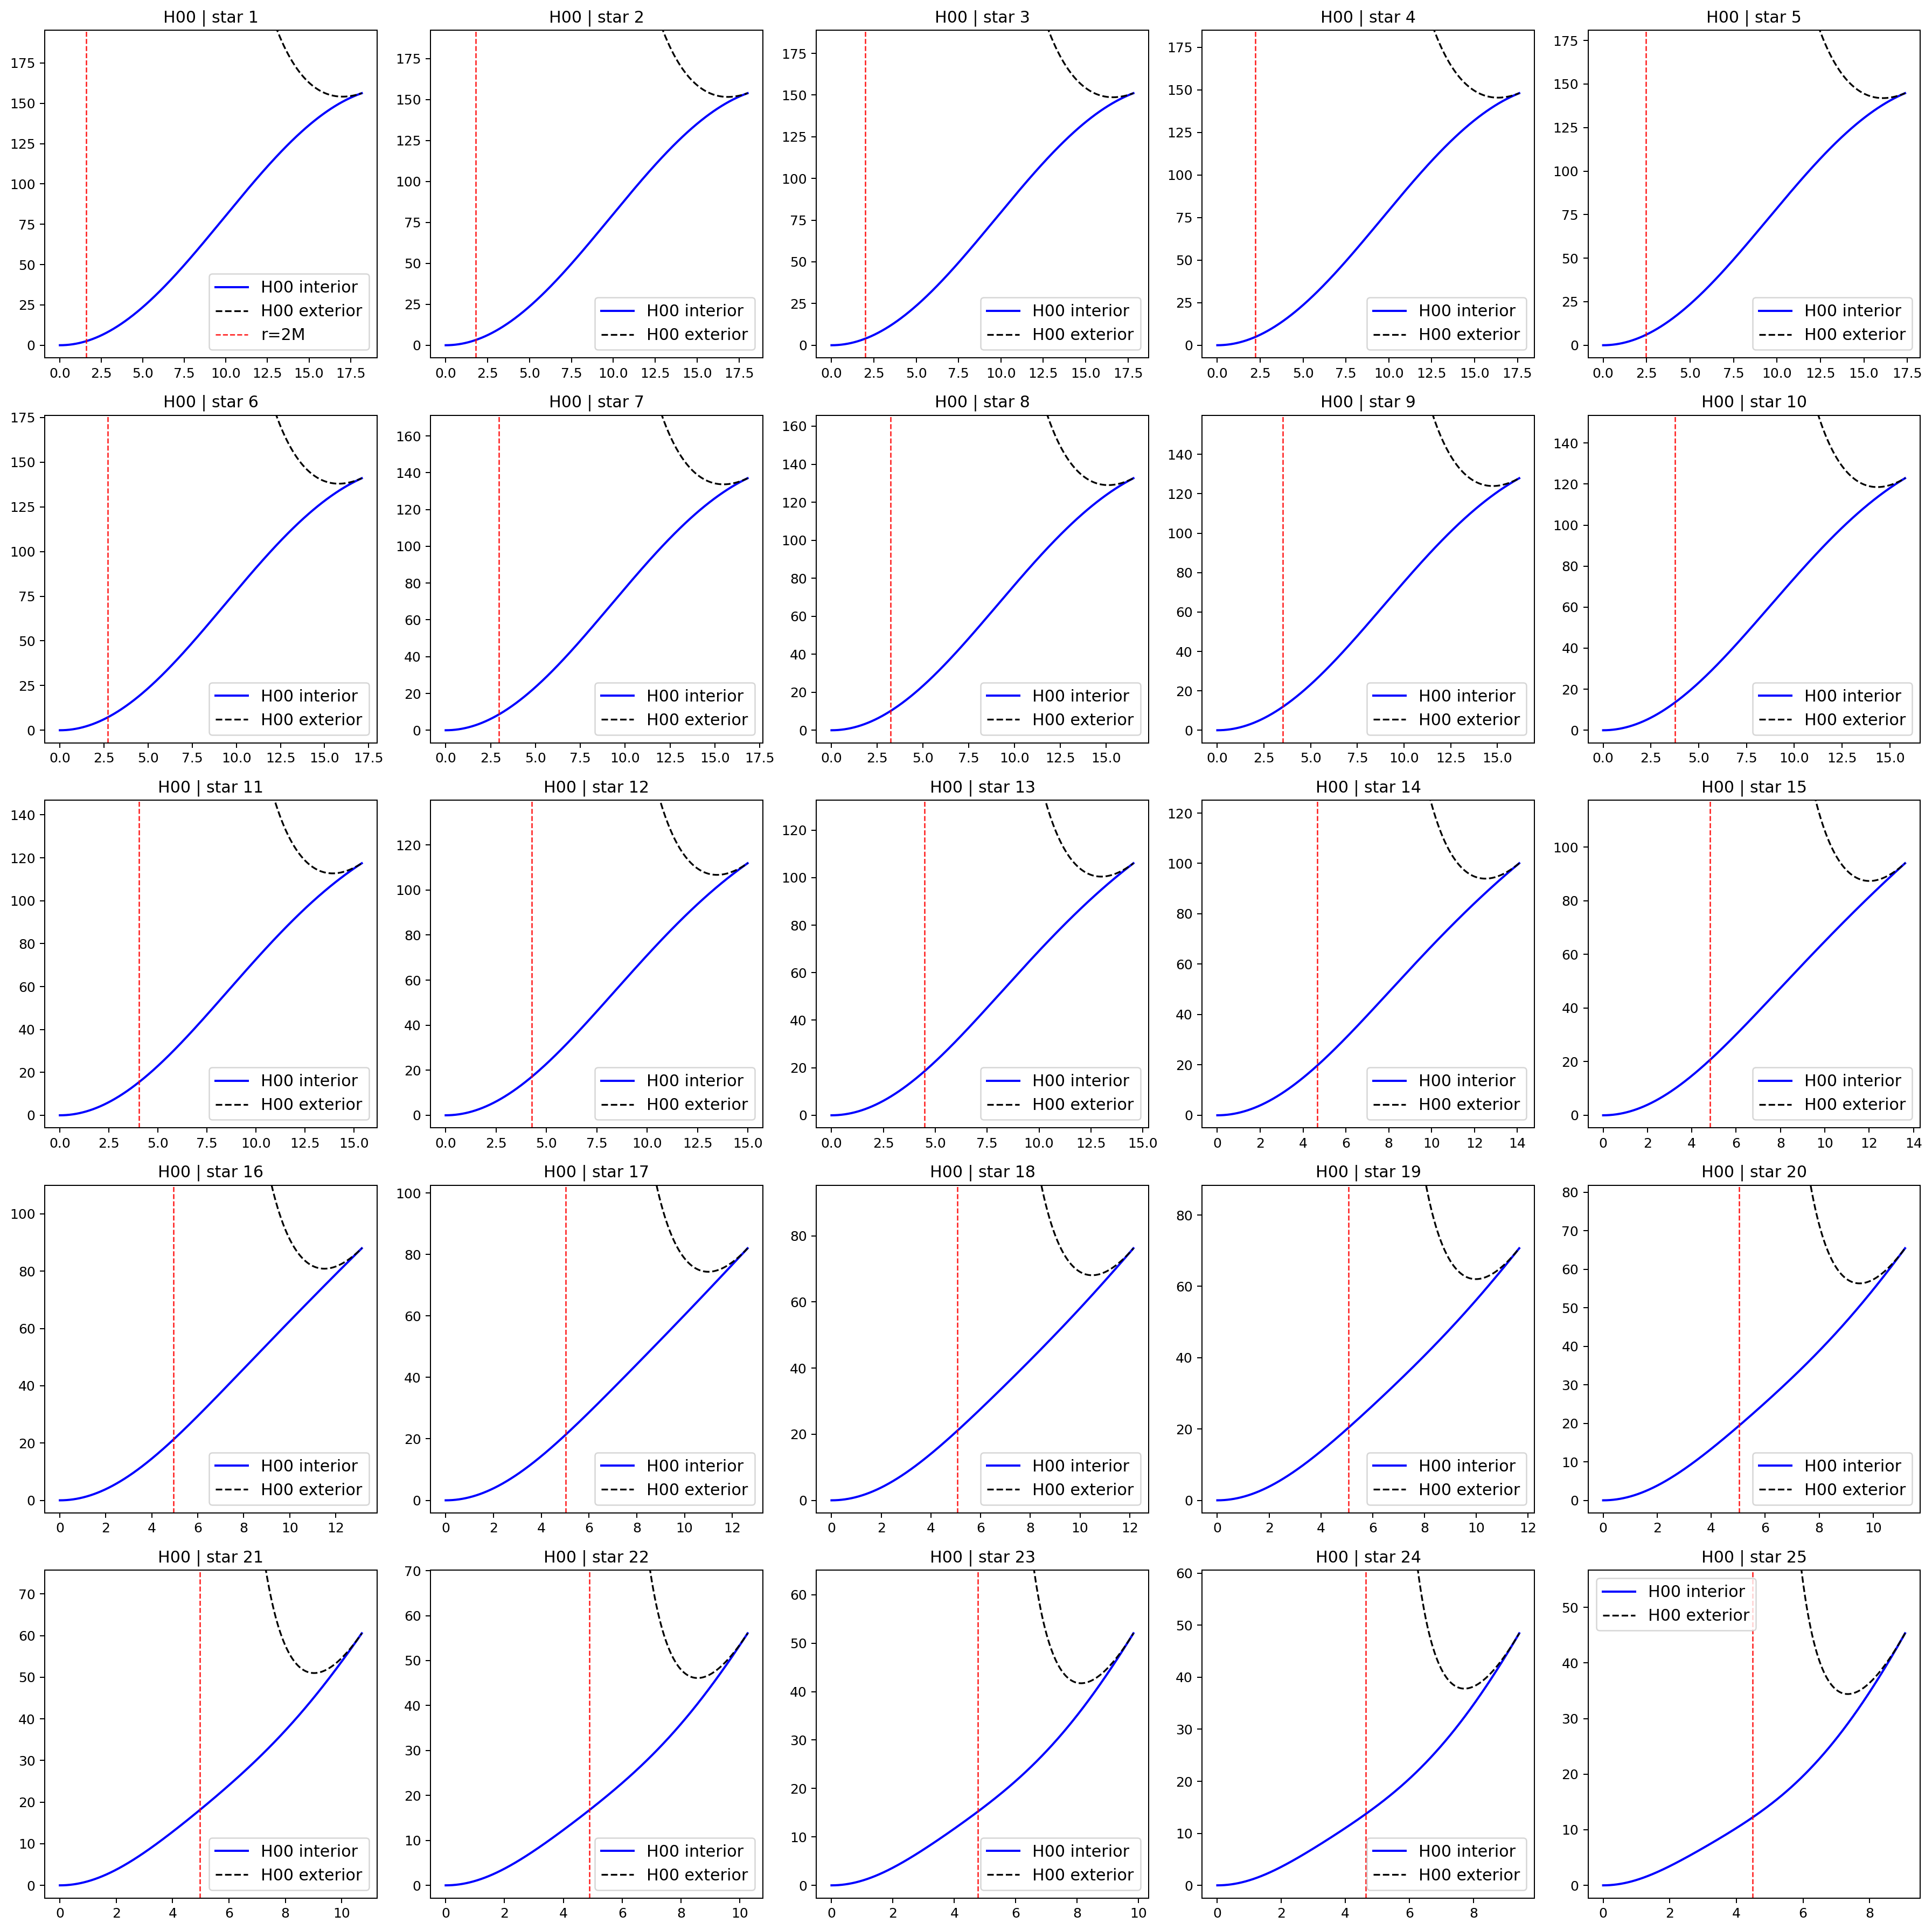

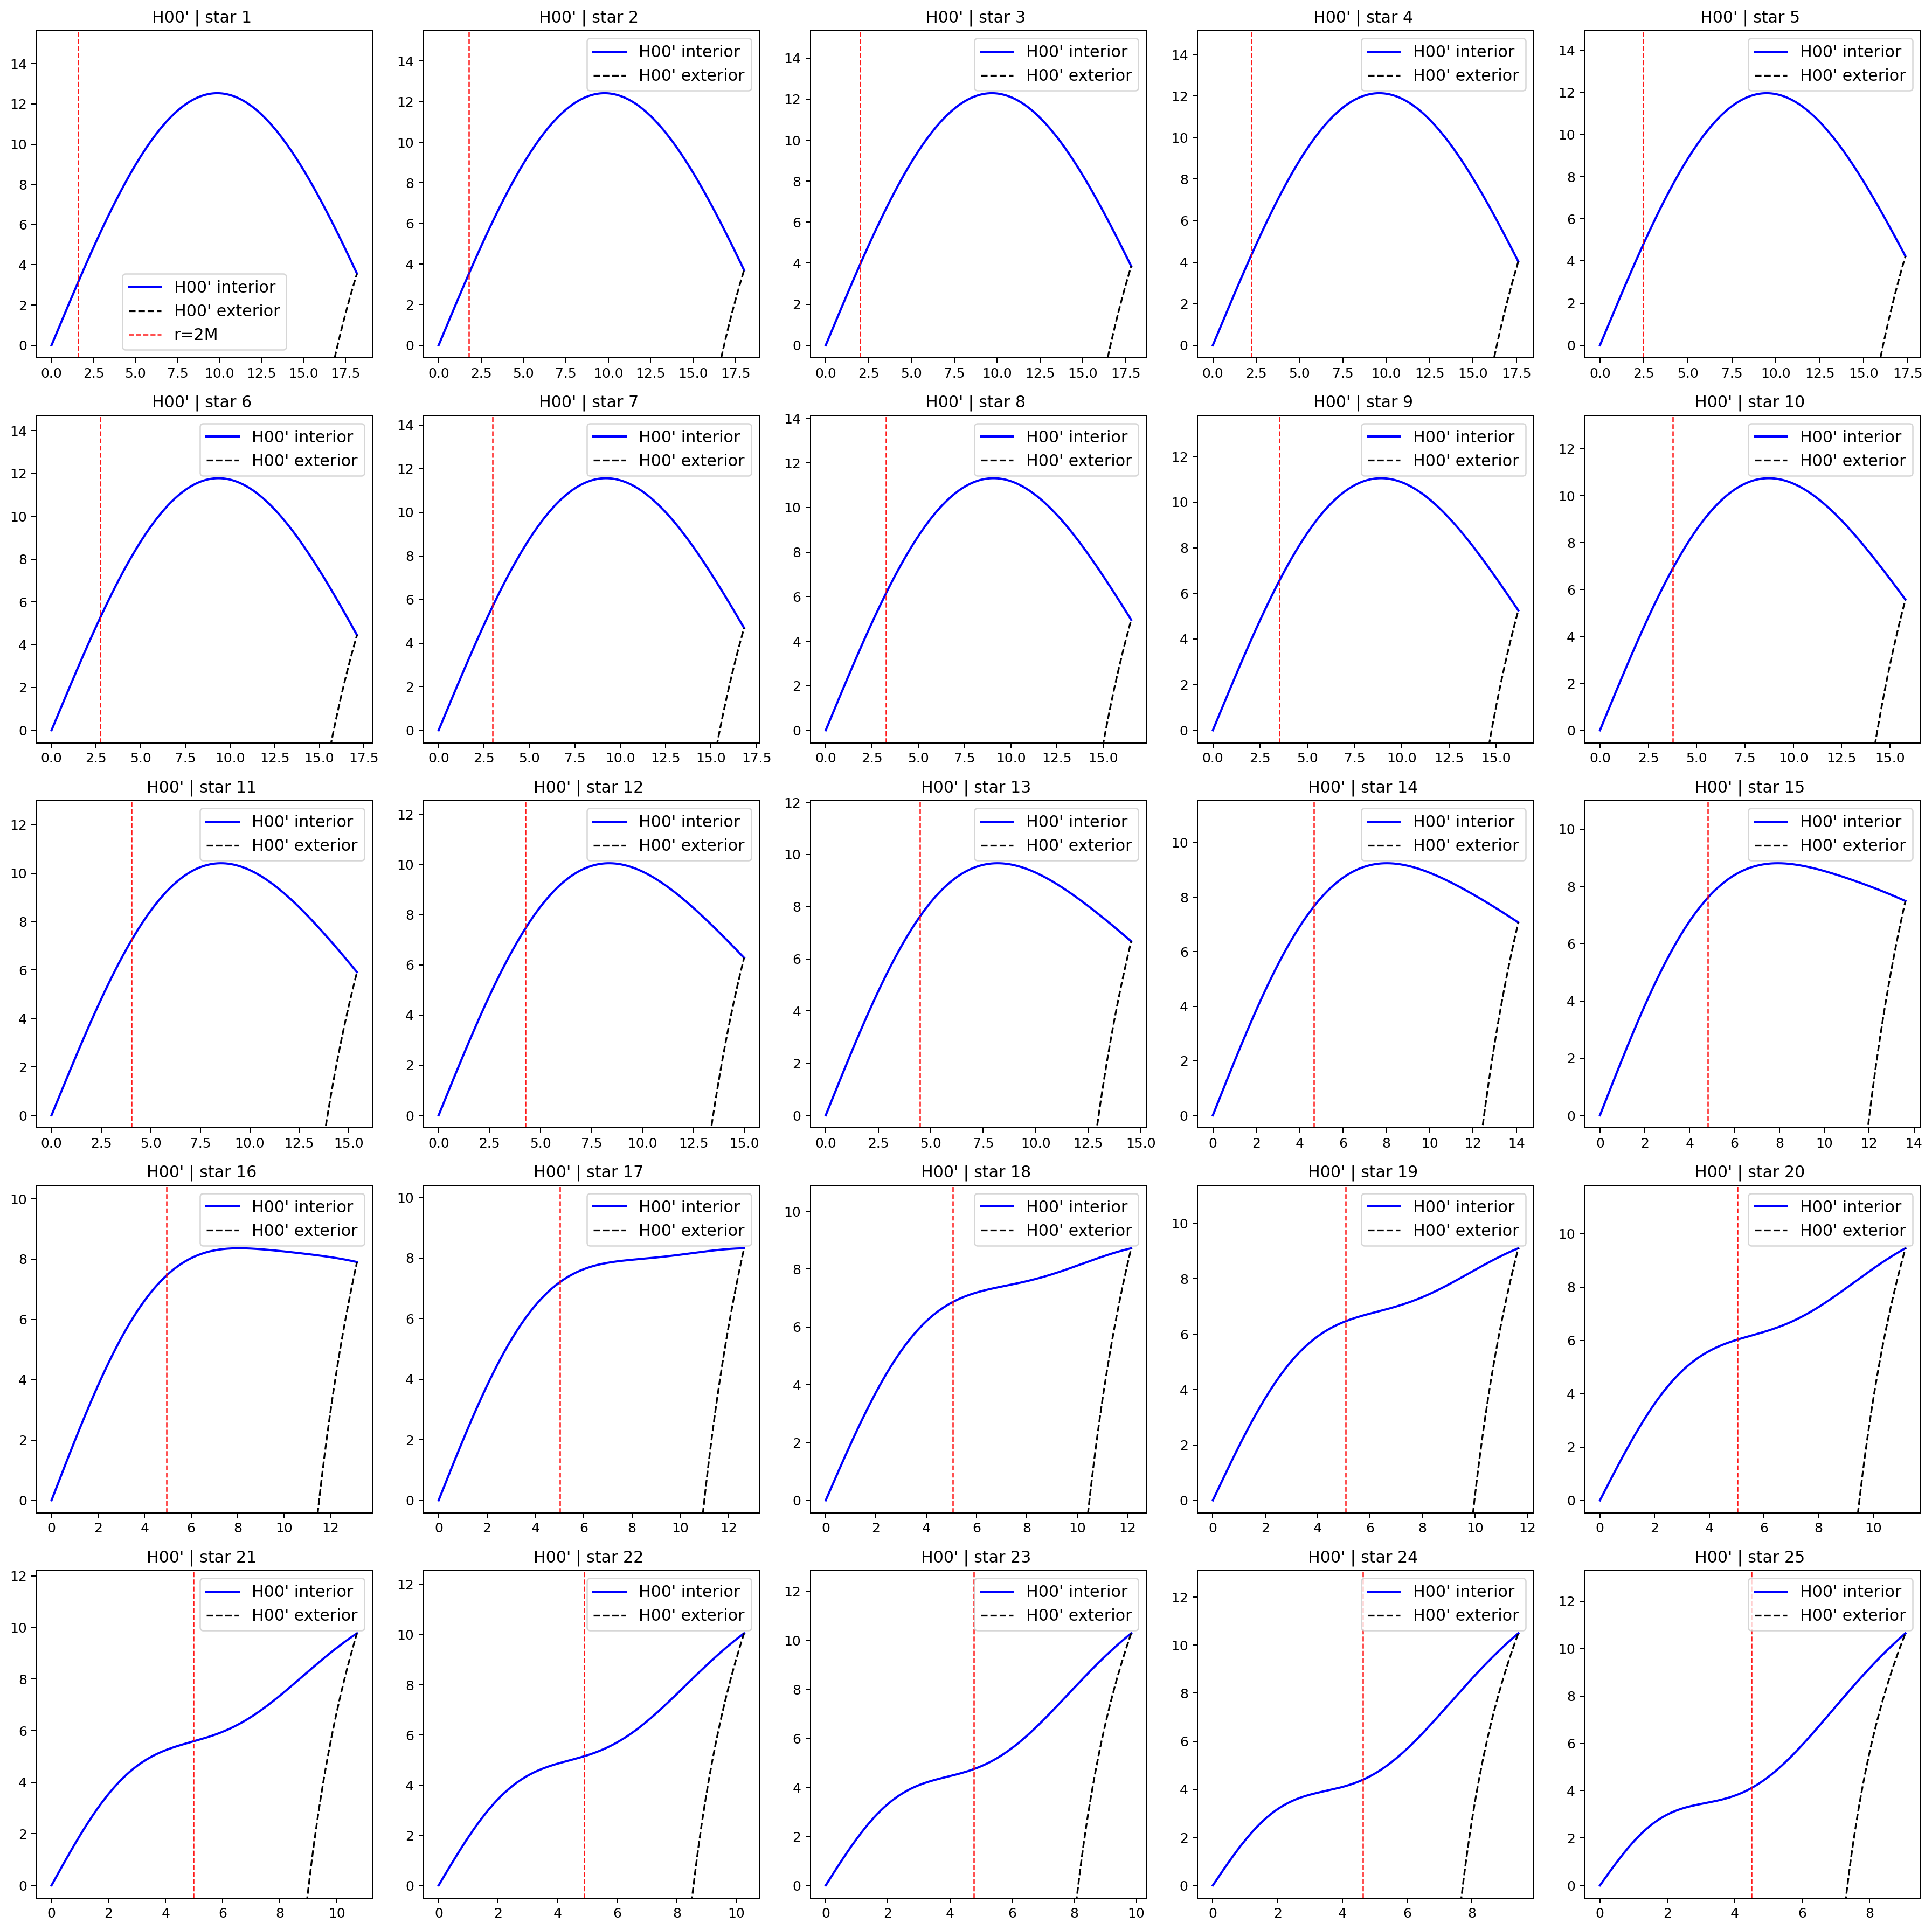

In [35]:
# 3) H00 Match Check and 4) H00' Match Check
rows, cols = grid_shape(n_plot_h00)

fig, axs = plt.subplots(rows, cols, figsize=(20, 4 * rows), dpi=180)
axs = np.atleast_1d(axs).reshape(rows, cols)
for i in range(rows * cols):
    ax = axs[i // cols, i % cols]
    if i >= n_plot_h00:
        ax.axis('off')
        continue

    d = h00_match_plot_data[i]
    r_s = 2.0 * d['M_tot']
    ax.plot(d['r'], d['h_in'], lw=1.6, color='blue', label='H00 interior')
    ax.plot(d['r'], d['h_out'], lw=1.3, ls='--', color='black', label='H00 exterior')
    ax.axvline(r_s, color='red', ls='--', lw=1.0, alpha=0.9, label='r=2M' if i == 0 else None)
    ax.set_title(f'H00 | star {i+1}')
    ax.legend(fontsize=12)

    scale = max(d['h_in']) - min(d['h_in'])
    ax.set_ylim(min(d['h_in']) - 0.05*scale, max(d['h_in']) + 0.25*scale)

fig.tight_layout()
plt.show()

fig, axs = plt.subplots(rows, cols, figsize=(20, 4 * rows), dpi=180)
axs = np.atleast_1d(axs).reshape(rows, cols)
for i in range(rows * cols):
    ax = axs[i // cols, i % cols]
    if i >= n_plot_h00:
        ax.axis('off')
        continue

    d = h00_match_plot_data[i]
    r_s = 2.0 * d['M_tot']
    ax.plot(d['r'], d['hp_in'], lw=1.6, color='blue', label="H00' interior")
    ax.plot(d['r'], d['hp_out'], lw=1.3, ls='--', color='black', label="H00' exterior")
    ax.axvline(r_s, color='red', ls='--', lw=1.0, alpha=0.9, label='r=2M' if i == 0 else None)
    ax.set_title(f"H00' | star {i+1} ")
    ax.legend(fontsize=12)

    scale = max(d['hp_in']) - min(d['hp_in'])
    ax.set_ylim(min(d['hp_in']) - 0.05*scale, max(d['hp_in']) + 0.25*scale)

fig.tight_layout()
plt.show()
